# Experiment setup and paths
Build paths and optional loaders used by the metric computation cells.

In [1]:
from tabpfn_project.paths import EXPERIMENTS_DATA_DIR, RESULTS_DIR, DISTNET_DATA_DIR
experiment_dir_cs = EXPERIMENTS_DATA_DIR / "experiment_context_sizes"
tabpfn_preds_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "tabpfn_preds_full"
results_dir = RESULTS_DIR / "experiment_context_sizes"
results_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# # Example usage (keep commented unless you want to regenerate per-scenario files)
# from tabpfn_project.globals import DISTNET_SCENARIOS
# from tabpfn_project.helper.utils import fetch_save_dict

# model_metadata_dirs = {
#     "baseline": experiment_dir_cs / "naive_baseline" / "metadata",
#     "rf_baseline": experiment_dir_cs / "random_forest" / "metadata",
# }

# for model_name, model_metadata_dir in model_metadata_dirs.items():
#     fetch_save_dict(results_dir, model_metadata_dir, model_name)

Saved to C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\baseline_all_scenarios.pkl
Saved to C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\rf_baseline_all_scenarios.pkl


# Models comparison: Global-View

Scenarios: ['clasp_factoring', 'saps-CVVAR', 'spear_qcp', 'yalsat_qcp', 'spear_swgcp', 'yalsat_swgcp', 'lpg-zeno']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
Models: ['tabpfn', 'distnet', 'rf_baseline', 'baseline']
Total aggregated entries: 1456


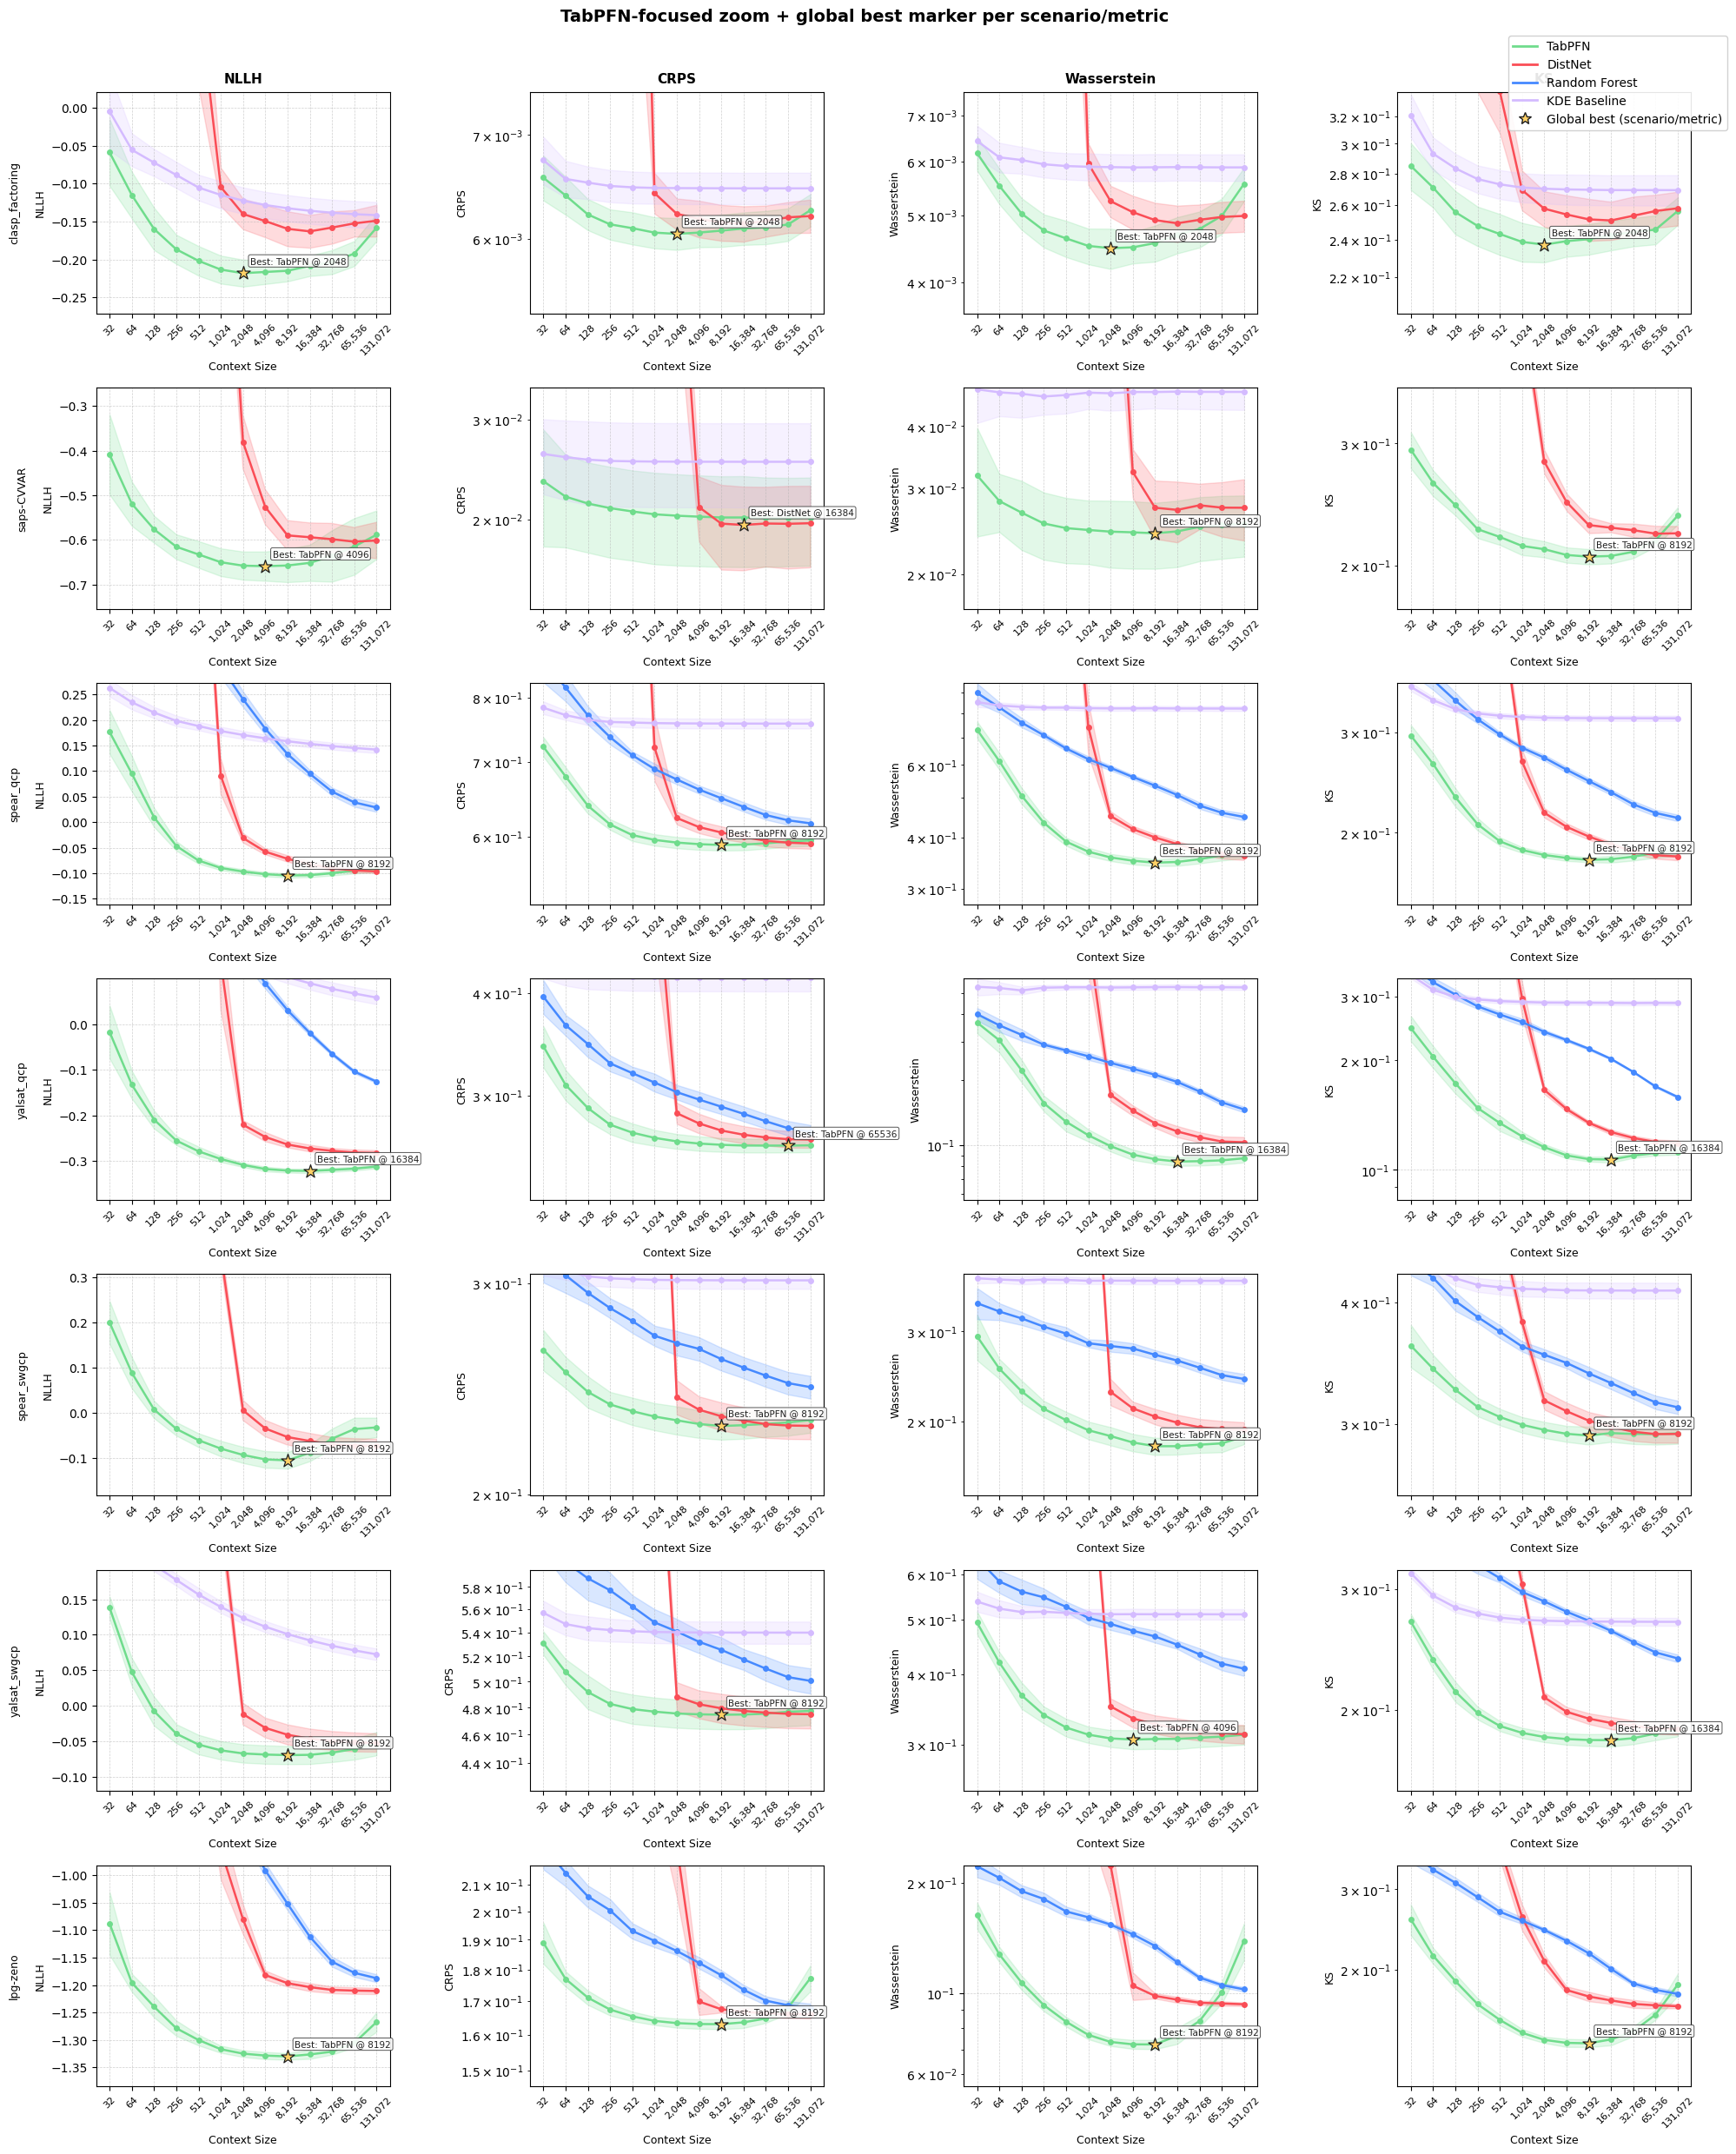

In [5]:
from collections import defaultdict
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tabpfn_project.paths import RESULTS_DIR
from tabpfn_project.globals import DISTNET_SCENARIOS

results_dir = RESULTS_DIR / "experiment_context_sizes"

with open(f"{results_dir}/tabpfn_context_size_results.pkl", "rb") as f:
    tabpfn_results = pickle.load(f)

with open(f"{results_dir}/distnet_context_size_results.pkl", "rb") as f:
    distnet_results = pickle.load(f)

with open(f"{results_dir}/rf_baseline_all_scenarios.pkl", "rb") as f:
    random_forest_results = pickle.load(f)
with open(f"{results_dir}/baseline_all_scenarios.pkl", "rb") as f:
    kde_baseline_results = pickle.load(f)

all_results = tabpfn_results + distnet_results + random_forest_results + kde_baseline_results

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# ------------------------------------------------------------------
# Aggregation strategy requested:
# 1) For each (model, scenario, context_size, fold), average over seeds
# 2) For each (model, scenario, context_size), average over folds
# 3) Shade with std across folds
# ------------------------------------------------------------------

# (model, scenario, context_size, fold, metric) -> list of seed-level run scores
seed_scores_by_fold = defaultdict(list)

for entry in all_results:
    model = entry["model"]
    scenario = entry["scenario"]
    context_size = entry["context_size"]
    fold = entry["fold"]
    inst_summ = entry["instance_summary"]

    for metric in METRICS:
        vals = inst_summ[metric]
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()

        # One score per seed-run: mean over instances
        run_score = float(vals.mean())
        seed_scores_by_fold[(model, scenario, context_size, fold, metric)].append(run_score)

# (model, scenario, context_size, metric) -> list of fold means
fold_means = defaultdict(list)

for key, seed_scores in seed_scores_by_fold.items():
    model, scenario, context_size, fold, metric = key
    fold_mean = float(np.mean(seed_scores))
    fold_means[(model, scenario, context_size, metric)].append(fold_mean)

# Final plot data: mean/std over folds
plot_data = {}
for key, fold_scores in fold_means.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, len(scores))

# Keep all known scenarios visible (7 rows expected)
scenarios = list(DISTNET_SCENARIOS)
context_sizes = sorted({k[2] for k in plot_data.keys()})
models = ["tabpfn", "distnet", "rf_baseline", "baseline"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")

MODEL_COLORS = {"tabpfn": "#6fdc8c", "distnet": "#fa4d56", "rf_baseline": "#4589ff", "baseline": "#d4bbff"}
MODEL_LABELS = {"tabpfn": "TabPFN", "distnet": "DistNet", "rf_baseline": "Random Forest", "baseline": "KDE Baseline"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}
LOG_METRICS = {"CRPS", "Wasserstein", "KS"}

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        tabpfn_zoom_means = None
        tabpfn_zoom_stds = None

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    m, s, n_folds = plot_data[key]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s)

            if not xs:
                continue

            xs = np.array(xs, dtype=float)
            means = np.array(means, dtype=float)
            stds = np.array(stds, dtype=float)

            if model == "tabpfn":
                tabpfn_zoom_means = means.copy()
                tabpfn_zoom_stds = stds.copy()

            color = MODEL_COLORS[model]
            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.8,
                color=color,
                label=MODEL_LABELS[model],
            )
            ax.fill_between(xs, means - stds, means + stds, alpha=0.20, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xticks(context_sizes)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        if metric in LOG_METRICS:
            ax.set_yscale("log")

        # Zoom each subplot to TabPFN behavior while keeping other models on the same axis.
        if tabpfn_zoom_means is not None and len(tabpfn_zoom_means) > 0:
            lower = tabpfn_zoom_means - tabpfn_zoom_stds
            upper = tabpfn_zoom_means + tabpfn_zoom_stds

            if metric in LOG_METRICS:
                lower = lower[lower > 0]
                upper = upper[upper > 0]
                if lower.size > 0 and upper.size > 0:
                    y_min = float(np.min(lower))
                    y_max = float(np.max(upper))
                    if y_max <= y_min:
                        y_max = y_min * 1.01
                    log_min = np.log10(y_min)
                    log_max = np.log10(y_max)
                    log_span = max(log_max - log_min, 1e-3)
                    pad_dec = 0.18 * log_span + 0.03
                    ax.set_ylim(10 ** (log_min - pad_dec), 10 ** (log_max + pad_dec))
            else:
                y_min = float(np.min(lower))
                y_max = float(np.max(upper))
                if y_max <= y_min:
                    ref = max(abs(y_min), 1.0)
                    y_min -= 0.01 * ref
                    y_max += 0.01 * ref
                span = y_max - y_min
                pad = 0.16 * span + 1e-10
                ax.set_ylim(y_min - pad, y_max + pad)

        # Best point among all models and all context sizes for this scenario/metric.
        candidate_points = []  # (score, context_size, model)
        for model in models:
            for cs in context_sizes:
                key = (model, scenario, cs, metric)
                if key in plot_data:
                    score = float(plot_data[key][0])
                    if metric in LOG_METRICS and score <= 0:
                        continue
                    candidate_points.append((score, cs, model))

        if candidate_points:
            best_score, best_cs, best_model = min(candidate_points, key=lambda t: (t[0], t[1]))
            y_low, y_high = ax.get_ylim()

            in_view = y_low <= best_score <= y_high
            if in_view:
                star_y = best_score
                label_suffix = ""
            else:
                if metric in LOG_METRICS:
                    star_y = y_high * 0.985 if best_score > y_high else y_low * 1.015
                else:
                    span = y_high - y_low
                    star_y = y_high - 0.02 * span if best_score > y_high else y_low + 0.02 * span
                label_suffix = " (off-scale)"

            ax.scatter(
                [best_cs],
                [star_y],
                marker="*",
                s=130,
                color="#ffd166",
                edgecolors="#1f1f1f",
                linewidths=0.9,
                zorder=6,
                clip_on=False,
            )
            ax.annotate(
                f"Best: {MODEL_LABELS[best_model]} @ {int(best_cs)}{label_suffix}",
                xy=(best_cs, star_y),
                xytext=(6, 8),
                textcoords="offset points",
                fontsize=7.5,
                color="#1f1f1f",
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "facecolor": "white",
                    "edgecolor": "#444444",
                    "alpha": 0.9,
                    "linewidth": 0.7,
                },
            )

        ax.set_xlabel("Context Size", fontsize=9)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
handles.append(
    matplotlib.lines.Line2D(
        [0],
        [0],
        marker="*",
        linestyle="None",
        markersize=10,
        markerfacecolor="#ffd166",
        markeredgecolor="#1f1f1f",
        label="Global best (scenario/metric)",
    )
)
fig.legend(
    handles=handles,
    loc="upper right",
    fontsize=10,
    framealpha=0.9,
    bbox_to_anchor=(1.0, 1.0),
)

plt.suptitle(
    "TabPFN-focused zoom + global best marker per scenario/metric",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Requires the Global-View cell to have been run (it creates plot_data and related variables).
required_vars = ["plot_data", "models", "scenarios", "context_sizes", "METRICS", "LOG_METRICS", "results_dir", "MODEL_LABELS"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. Run Cell 7 (Models comparison: Global-View) first."
    )

# 1) Full aggregated table used for plotting.
rows = []
for model in models:
    for scenario in scenarios:
        for metric in METRICS:
            for context_size in context_sizes:
                key = (model, scenario, context_size, metric)
                if key not in plot_data:
                    continue
                mean_over_folds, std_over_folds, n_folds = plot_data[key]
                rows.append(
                    {
                        "model": model,
                        "model_label": MODEL_LABELS.get(model, model),
                        "scenario": scenario,
                        "metric": metric,
                        "context_size": int(context_size),
                        "mean_over_folds": float(mean_over_folds),
                        "std_over_folds": float(std_over_folds),
                        "n_folds": int(n_folds),
                    }
                )

agg_df = pd.DataFrame(rows).sort_values(["scenario", "metric", "model", "context_size"])

# 2) Best row per (scenario, metric), considering all models and all context sizes.
best_rows = []
for scenario in scenarios:
    for metric in METRICS:
        block = agg_df[(agg_df["scenario"] == scenario) & (agg_df["metric"] == metric)].copy()
        if block.empty:
            continue

        if metric in LOG_METRICS:
            block = block[block["mean_over_folds"] > 0].copy()
            if block.empty:
                continue

        block = block.sort_values(["mean_over_folds", "context_size"], ascending=[True, True])
        best = block.iloc[0]
        best_rows.append(
            {
                "scenario": scenario,
                "metric": metric,
                "best_model": best["model"],
                "best_model_label": best["model_label"],
                "best_context_size": int(best["context_size"]),
                "best_mean_over_folds": float(best["mean_over_folds"]),
                "best_std_over_folds": float(best["std_over_folds"]),
                "best_n_folds": int(best["n_folds"]),
            }
        )

best_df = pd.DataFrame(best_rows).sort_values(["scenario", "metric"])

# 3) Save publication-ready CSV files.
out_full = results_dir / "global_view_aggregated_scores.csv"
out_best = results_dir / "global_view_best_points_all_models.csv"

agg_df.to_csv(out_full, index=False)
best_df.to_csv(out_best, index=False)

print(f"Saved full aggregated table: {out_full} ({len(agg_df)} rows)")
print(f"Saved best-points table: {out_best} ({len(best_df)} rows)")

Saved full aggregated table: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\global_view_aggregated_scores.csv (1456 rows)
Saved best-points table: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\global_view_best_points_all_models.csv (28 rows)


In [2]:
import pandas as pd

full_table_path = results_dir / "global_view_aggregated_scores.csv"
out_best_per_model_path = results_dir / "best_context_size_per_model_scenario_metric.csv"

if not full_table_path.exists():
    raise FileNotFoundError(f"Input CSV not found: {full_table_path}")

df = pd.read_csv(full_table_path)

required_cols = ["model", "scenario", "metric", "context_size", "mean_over_folds"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in input CSV: {missing_cols}")

# Lower is better for all metrics in this project. Break ties using smaller context_size.
best_per_group = (
    df.sort_values(["model", "scenario", "metric", "mean_over_folds", "context_size"], ascending=[True, True, True, True, True])
      .groupby(["model", "scenario", "metric"], as_index=False)
      .first()
      .rename(columns={
          "context_size": "best_context_size",
          "mean_over_folds": "best_mean_over_folds",
          "std_over_folds": "best_std_over_folds",
          "n_folds": "best_n_folds",
      })
      .sort_values(["scenario", "metric", "model"])
      .reset_index(drop=True)
)

best_per_group.to_csv(out_best_per_model_path, index=False)

print(f"Loaded: {full_table_path} ({len(df)} rows)")
print(f"Saved:  {out_best_per_model_path} ({len(best_per_group)} rows)")
best_per_group.head(12)

Loaded: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\global_view_aggregated_scores.csv (1456 rows)
Saved:  C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\best_context_size_per_model_scenario_metric.csv (112 rows)


,model,scenario,metric,model_label,best_context_size,best_mean_over_folds,best_std_over_folds,best_n_folds
0,baseline,clasp_factoring,CRPS,KDE Baseline,131072,0.006468,0.000152,10
1,distnet,clasp_factoring,CRPS,DistNet,16384,0.006137,0.000161,10
2,rf_baseline,clasp_factoring,CRPS,Random Forest,131072,0.023890,0.000022,10
3,tabpfn,clasp_factoring,CRPS,TabPFN,2048,0.006045,0.000142,10
4,baseline,clasp_factoring,KS,KDE Baseline,131072,0.269247,0.009583,10
5,distnet,clasp_factoring,KS,DistNet,16384,0.250889,0.011203,10
6,rf_baseline,clasp_factoring,KS,Random Forest,131072,0.443194,0.001140,10
7,tabpfn,clasp_factoring,KS,TabPFN,2048,0.237112,0.009606,10
8,baseline,clasp_factoring,NLLH,KDE Baseline,131072,-0.141663,0.017370,10
9,distnet,clasp_factoring,NLLH,DistNet,16384,-0.163016,0.021584,10


In [5]:
import pandas as pd

# Input from previous cell: best context size per (model, scenario, metric).
in_best_per_metric = results_dir / "best_context_size_per_model_scenario_metric.csv"
out_mode_per_model_scenario_path = results_dir / "best_context_size_mode_per_model_scenario.csv"

if not in_best_per_metric.exists():
    raise FileNotFoundError(
        f"Missing input file: {in_best_per_metric}. Run Cell 8 first."
    )

best_metric_df = pd.read_csv(in_best_per_metric)

required_cols = ["model", "scenario", "metric", "best_context_size"]
missing_cols = [c for c in required_cols if c not in best_metric_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

def pick_mode_with_smallest_tiebreak(series: pd.Series) -> int:
    counts = series.value_counts(dropna=True)
    if counts.empty:
        return pd.NA
    max_count = counts.max()
    candidates = counts[counts == max_count].index.tolist()
    return int(min(candidates))

# Per (model, scenario): mode of best_context_size across metrics.
summary_per_model_scenario = (
    best_metric_df.groupby(["model", "scenario"], as_index=False)
    .agg(
        best_context_size_mode=("best_context_size", pick_mode_with_smallest_tiebreak),
        n_metrics=("metric", "nunique"),
        total_votes=("best_context_size", "size"),
    )
)

# Support count: how many metric-votes selected the modal context size in each (model, scenario).
mode_support = (
    best_metric_df.merge(
        summary_per_model_scenario[["model", "scenario", "best_context_size_mode"]],
        on=["model", "scenario"],
        how="inner",
    )
    .query("best_context_size == best_context_size_mode")
    .groupby(["model", "scenario"], as_index=False)
    .agg(mode_count=("best_context_size", "size"))
)

summary_per_model_scenario = (
    summary_per_model_scenario
    .merge(mode_support, on=["model", "scenario"], how="left")
    .sort_values(["scenario", "model"])
.reset_index(drop=True)
)

summary_per_model_scenario.to_csv(out_mode_per_model_scenario_path, index=False)

print(f"Loaded per-metric best table:   {in_best_per_metric} ({len(best_metric_df)} rows)")
print(f"Saved per-model/scenario mode: {out_mode_per_model_scenario_path} ({len(summary_per_model_scenario)} rows)")
summary_per_model_scenario.head(20)

Loaded per-metric best table:   C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\best_context_size_per_model_scenario_metric.csv (112 rows)
Saved per-model/scenario mode: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\best_context_size_mode_per_model_scenario.csv (28 rows)


,model,scenario,best_context_size_mode,n_metrics,total_votes,mode_count
0,baseline,clasp_factoring,131072,4,4,3
1,distnet,clasp_factoring,16384,4,4,4
2,rf_baseline,clasp_factoring,131072,4,4,4
3,tabpfn,clasp_factoring,2048,4,4,4
4,baseline,lpg-zeno,131072,4,4,3
5,distnet,lpg-zeno,131072,4,4,4
6,rf_baseline,lpg-zeno,131072,4,4,4
7,tabpfn,lpg-zeno,8192,4,4,4
8,baseline,saps-CVVAR,131072,4,4,2
9,distnet,saps-CVVAR,16384,4,4,2
